In [1]:
%reset -f
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
from pathlib import Path
from src.data import Pacman_Dataset, TorusLieWrapper, AngleTorusWrapper
from torch.utils.data import DataLoader


In [2]:
# file_path = Path(os.getcwd())
# project_path = file_path.parent
# project_path = os.fspath(project_path)
project_path = os.path.abspath('')
print(project_path)
print(torch.cuda.is_available())

/Users/jizho/project_codes/diffusion-playground
False


In [3]:
data_directory = project_path + "/data"
pacman_data_dir = data_directory + "/pacman.npy"
pacman_np = np.load(pacman_data_dir)

Shape of pacman dataset: (486662, 2)


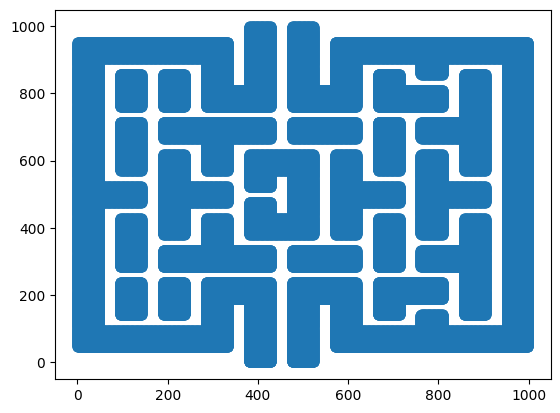

In [4]:
print("Shape of pacman dataset:", pacman_np.shape)

pacman_np
# sns.set_theme(style="whitegrid")
fig, ax = plt.subplots()
ax.scatter(x=pacman_np[:,0],y = pacman_np[:,1])
plt.show()
# sns.scatterplot(data=pacman_np)

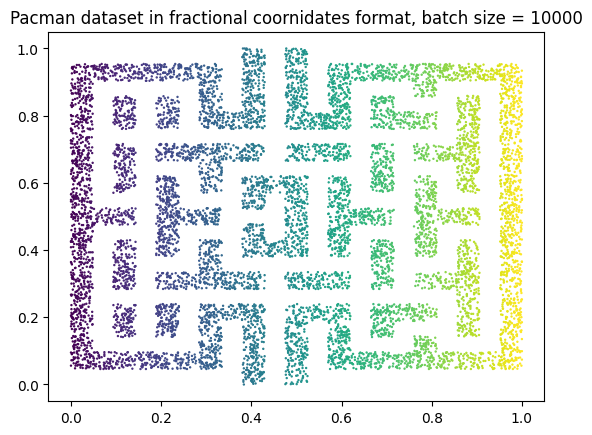

In [5]:
pacman_dataset = Pacman_Dataset(pacman_data_dir)

dataloader_fractional = DataLoader(pacman_dataset, batch_size=10000, shuffle=True)

batch_1_fractional = next(iter(dataloader_fractional))
fig, ax = plt.subplots()

ax.scatter(x=batch_1_fractional[:,0],y = batch_1_fractional[:,1], c = batch_1_fractional[:,0], cmap = "viridis", s = 0.5)
ax.set_title("Pacman dataset in fractional coornidates format, batch size = 10000")
plt.show()


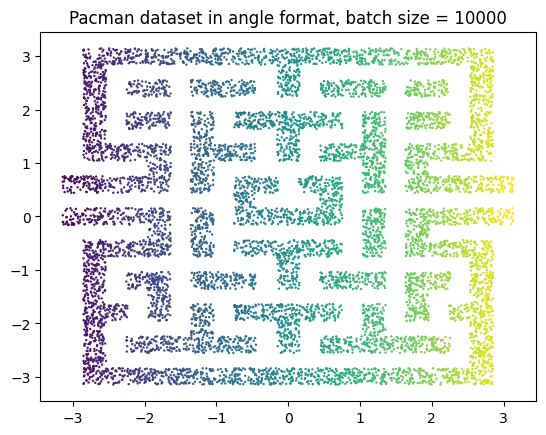

In [6]:


pacman_lie_dataset = TorusLieWrapper(pacman_dataset)
pacman_angle_dataset = AngleTorusWrapper(pacman_lie_dataset)
dataloader = DataLoader(pacman_angle_dataset, batch_size=10000, shuffle=True)
batch_1 = next(iter(dataloader))
fig, ax = plt.subplots()
ax.scatter(x=batch_1[:,1],y = -batch_1[:,0], c = batch_1[:,1], cmap = "viridis", s = 0.5)
ax.set_title("Pacman dataset in angle format, batch size = 10000")
plt.show()





In [7]:
from src.diffusion import TDMDiffusion
from src.scoreNN import TDM_SimpleScoreMLP

device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"
batch_size = 512
n_epoch = 50
lr = 1e-3
total_time = 2.0
# data shape: each sample -> (dim,)
dim = 2
# model
x_lifting_dim = 64
time_embedding_half_dim = 32  # must be even
time_embedding_scale = 1.0
position_fourier_bands = 8
t_dist_kw = "uniform"
use_weighted_loss = True
hidden_dim = [512,512]
output_dim = dim
model = TDMDiffusion(dim=dim, integrator_type="Euler", simplified_param=True).to(device)
score_nn = TDM_SimpleScoreMLP(
    dim=dim,
    x_lifting_dim=x_lifting_dim,
    time_embedding_half_dim=time_embedding_half_dim,
    time_embedding_scale=time_embedding_scale,
    position_fourier_bands=position_fourier_bands,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    with_sincos_position=True,
    only_sincos_position=True
).to(device)
state_dict = torch.load("simple_score_mlp_pacman.pt", map_location="cpu")
score_nn.load_state_dict(state_dict)

<All keys matched successfully>

torch.Size([10000, 2])
torch.Size([1, 2])
torch.Size([10000, 2])
tensor([[ 0.1016, -0.0497],
        [ 0.0699, -0.8356],
        [ 0.0386, -1.2824],
        ...,
        [ 0.0736,  1.3757],
        [ 0.1061,  0.9309],
        [ 0.1016, -0.0497]], grad_fn=<AddmmBackward0>)
tensor([0.1070, 0.6403, 0.9341,  ..., 0.9207, 0.5832, 0.1070],
       grad_fn=<StdBackward0>) tensor([-0.0479, -0.0103], grad_fn=<MeanBackward1>)
torch.Size([10000, 2])
tensor(-3.2109) tensor(2.2707)
tensor(-3.0295) tensor(3.0428)
torch.Size([3334, 1])


/Users/jizho/miniforge3/envs/diffusion-playground-torch/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


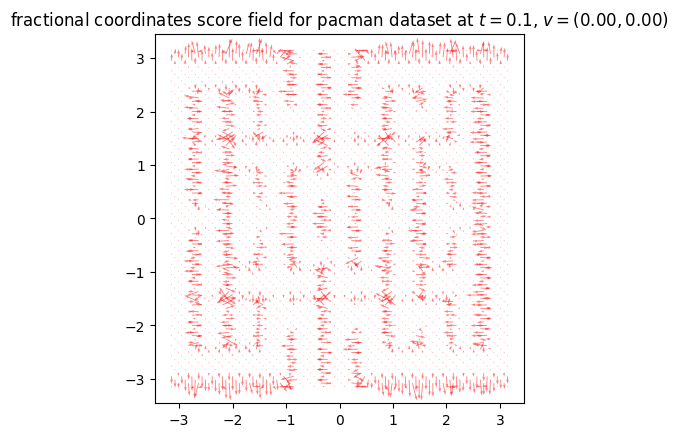

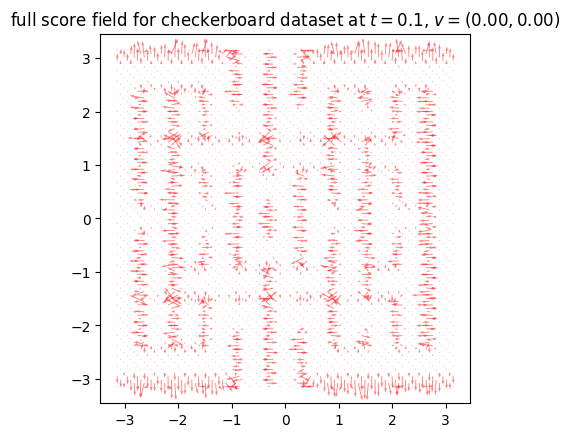

In [8]:
x_test = torch.linspace(-np.pi, np.pi, 100)
y_test = torch.linspace(-np.pi, np.pi, 100)
x_test, y_test = torch.meshgrid(x_test, y_test)
x_test = x_test.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
x_test = torch.cat([x_test, y_test], dim=-1)

x_test_batched = x_test[:,:]
print(x_test_batched.shape)
t_scalar = 0.1
v_scalar = torch.Tensor([[0,0]])
print(v_scalar.shape)
print(x_test_batched.shape)
t_test = torch.full((10000, 1), t_scalar)   # (1, 10000, 1)
v_test = torch.ones_like(x_test_batched) * v_scalar

score = score_nn(x_test_batched, v_test, t_test)
print(score)
print(score.std(dim=1),score.mean(dim=0))
score = score.detach().cpu()
print(score.shape)
print(min(score[:,0]),max(score[:,0]))
print(min(score[:,1]),max(score[:,1]))

# shows every 3 points
score = score[::3,:]
x_test_batched = x_test_batched[::3,:]
t_test = t_test[::3,:]
v_test = v_test[::3,:]
print(t_test.shape)

fig,ax = plt.subplots()
# ax.scatter(x_test[:,0],x_test[:,1],c=x_test[:,0],cmap = "viridis",s = 0.5,alpha = 0.5)
ax.quiver(x_test_batched[:,0],x_test_batched[:,1],score[:,0],score[:,1],color = "red",alpha = 0.5)
ax.set_aspect("equal")
ax.set_title(f"fractional coordinates score field for pacman dataset at $t = {t_scalar}$, $v = ({v_scalar[0,0]:.2f}, {v_scalar[0,1]:.2f})$")
plt.show()

score_v = (1- torch.exp(-t_test))/(1 + torch.exp(-t_test)) * score - v_test/ (model.sde.sigma_t(t_test)**2)

fig,ax = plt.subplots()
ax.quiver(x_test_batched[:,0],x_test_batched[:,1],score_v[:,0],score_v[:,1],color = "red",alpha = 0.5)
ax.set_aspect("equal")
ax.set_title(f"full score field for checkerboard dataset at $t = {t_scalar}$, $v = ({v_scalar[0,0]:.2f}, {v_scalar[0,1]:.2f})$")
plt.show()


In [27]:
ft_list, vt_list, t_list = model.sample_backward(
    fT_prior_kw="uniform", 
    vT_prior_kw="stdGauss", 
    data_shape=(5000, 2), 
    total_time=2.0,
    tdm_score_fn=score_nn,
    sample_trajectory=True,
    n_steps = 50,
    exponential_integration=False,
    probability_flow=False,
    predictor_corrector=True,
    predictor_corrector_n_steps=10,
    only_correct_vt = True,
    tau = 1e-3
)

ft_flow_list, vt_flow_list, t_flow_list = model.sample_backward(
    fT_prior_kw="uniform", 
    vT_prior_kw="stdGauss", 
    data_shape=(5000, 2), 
    total_time=2.0,
    tdm_score_fn=score_nn,
    sample_trajectory=True,
    n_steps = 50,
    exponential_integration=False,
    probability_flow=True
)

ft_em_list, vt_em_list, t_em_list = model.sample_backward(
    fT_prior_kw="uniform", 
    vT_prior_kw="stdGauss", 
    data_shape=(5000, 2), 
    total_time=2.0,
    tdm_score_fn=score_nn,
    probability_flow=False,
    n_steps = 50,
    exponential_integration=False,
    predictor_corrector=False,
    sample_trajectory=True
)




/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_4371/899079751.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(fT_init[:,0],fT_init[:,1],c="darkorange",cmap = "viridis",s = 0.5,alpha = 0.5)
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_4371/899079751.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(f0_final[:,0],f0_final[:,1],c="darkorange",cmap = "viridis",s = 0.5,alpha = 0.5)
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_4371/899079751.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(vT_init[:,0],vT_init[:,1],c="darkorange",cmap = "viridis",s = 0.5,alpha = 0.5)
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_4371/899079751.py:40: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(v0_final[:,0],v0_final[:,

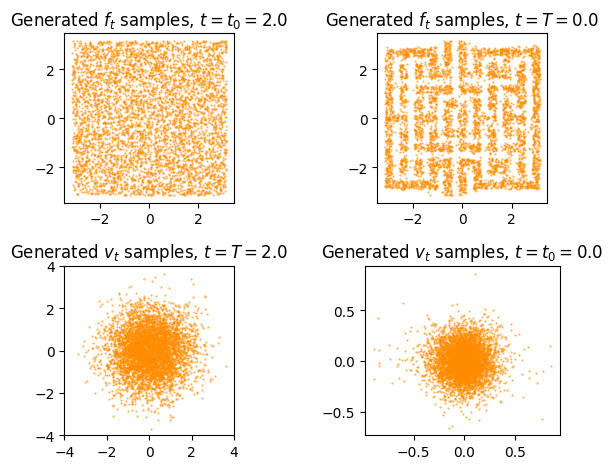

/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_4371/899079751.py:59: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(f0_final[:,0], f0_final[:,1], c="darkorange", cmap="viridis", s=0.5, alpha=0.5)
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_4371/899079751.py:65: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(f0_flow_final[:,0], f0_flow_final[:,1], c="darkorange", cmap="viridis", s=0.5, alpha=0.5)
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_4371/899079751.py:71: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(f0_em_final[:,0], f0_em_final[:,1], c="darkorange", cmap="viridis", s=0.5, alpha=0.5)
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_4371/899079751.py:77: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(v0_final

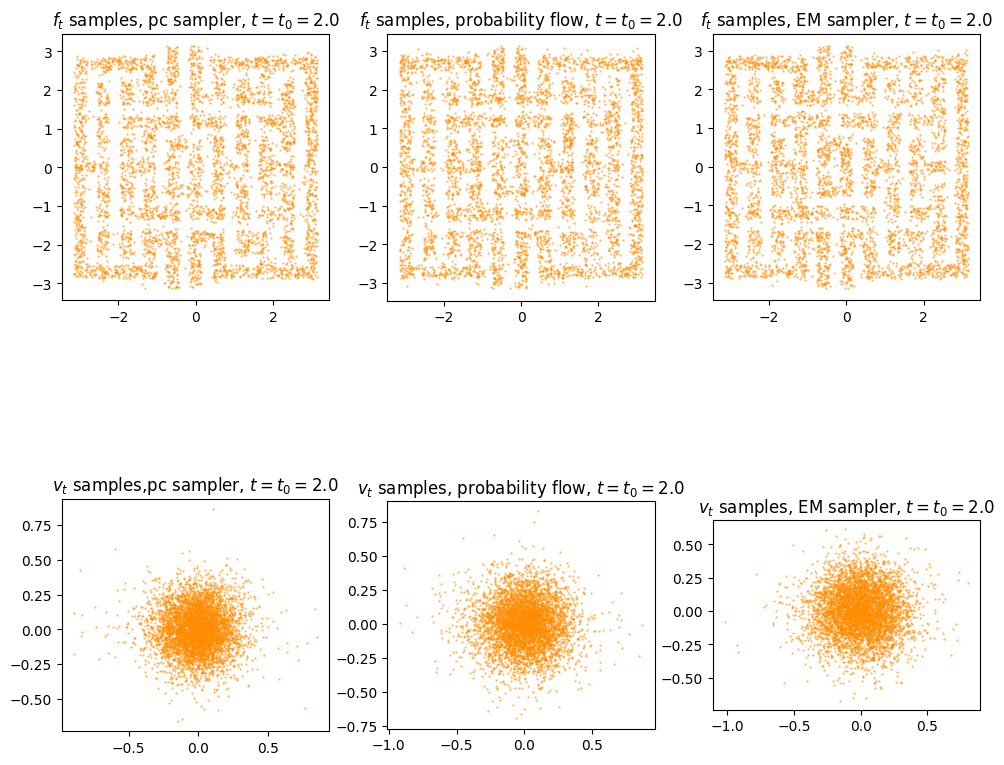

In [28]:
fT_init = ft_list[0]
vT_init = vt_list[0]
t_T = t_list[0]


fT_init = fT_init.detach().cpu()
vT_init = vT_init.detach().cpu()

f0_final = ft_list[-1].detach().cpu()
v0_final = vt_list[-1].detach().cpu()
t_0 = t_list[-1]


fig,axes = plt.subplots(2,2)



ax = axes[0,0]
ax.scatter(fT_init[:,0],fT_init[:,1],c="darkorange",cmap = "viridis",s = 0.5,alpha = 0.5)
ax.set_aspect("equal")
ax.set_title(f"Generated $f_t$ samples, $t = t_0 = {t_T}$")
# plt.show()


ax = axes[0,1]
ax.scatter(f0_final[:,0],f0_final[:,1],c="darkorange",cmap = "viridis",s = 0.5,alpha = 0.5)
ax.set_aspect("equal")
ax.set_title(f"Generated $f_t$ samples, $t = T = {t_0}$")
# plt.show()

ax = axes[1,0]
ax.scatter(vT_init[:,0],vT_init[:,1],c="darkorange",cmap = "viridis",s = 0.5,alpha = 0.5)
ax.set_aspect("equal")
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)
ax.set_title(f"Generated $v_t$ samples, $t = T = {t_T}$")
# plt.show()

ax = axes[1,1]
ax.scatter(v0_final[:,0],v0_final[:,1],c="darkorange",cmap = "viridis",s = 0.5,alpha = 0.5)
ax.set_aspect("equal")
ax.set_title(f"Generated $v_t$ samples, $t = t_0 = {t_0}$")
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(2, 3, figsize=(10, 10))

f0_flow_final = ft_flow_list[-1].detach().cpu()
v0_flow_final = vt_flow_list[-1].detach().cpu()

f0_em_final = ft_em_list[-1].detach().cpu()
v0_em_final = vt_em_list[-1].detach().cpu()


# Top-left: f_t at t=t0
ax = axes[0, 0]
ax.scatter(f0_final[:,0], f0_final[:,1], c="darkorange", cmap="viridis", s=0.5, alpha=0.5)
ax.set_aspect("equal")
ax.set_title(f"$f_t$ samples, pc sampler, $t = t_0 = {t_T}$")

# Top-right: f_t at t=T
ax = axes[0, 1]
ax.scatter(f0_flow_final[:,0], f0_flow_final[:,1], c="darkorange", cmap="viridis", s=0.5, alpha=0.5)
ax.set_aspect("equal")
ax.set_title(f"$f_t$ samples, probability flow, $t = t_0 = {t_T}$")


ax = axes[0, 2]
ax.scatter(f0_em_final[:,0], f0_em_final[:,1], c="darkorange", cmap="viridis", s=0.5, alpha=0.5)
ax.set_aspect("equal")
ax.set_title(f"$f_t$ samples, EM sampler, $t = t_0 = {t_T}$")

# Bottom-left: v_t at t=t0
ax = axes[1, 0]
ax.scatter(v0_final[:,0], v0_final[:,1], c="darkorange", cmap="viridis", s=0.5, alpha=0.5)
ax.set_aspect("equal")
# ax.set_xlim(-4, 4)
# ax.set_ylim(-4, 4)
ax.set_title(f"$v_t$ samples,pc sampler, $t = t_0 = {t_T}$")

# Bottom-right: v_t at t=T
ax = axes[1, 1]
ax.scatter(v0_flow_final[:,0], v0_flow_final[:,1], c="darkorange", cmap="viridis", s=0.5, alpha=0.5)
ax.set_aspect("equal")
ax.set_title(f"$v_t$ samples, probability flow, $t = t_0 = {t_T}$")

ax = axes[1, 2]
ax.scatter(v0_em_final[:,0], v0_em_final[:,1], c="darkorange", cmap="viridis", s=0.5, alpha=0.5)
ax.set_aspect("equal")
ax.set_title(f"$v_t$ samples, EM sampler, $t = t_0 = {t_T}$")

plt.tight_layout()
plt.show()




In [29]:
import scipy.stats as stats
import scipy.special as special
# wasserstein_dist = stats.wasserstein_distance_nd(batch_1, fT_final)
# print(wasserstein_dist)